### Распределение эмбеддингов текстов. 
Энкодер: all-MiniLM-L6-v2

In [1]:
SEED = 42
ENCODER = "sentence-transformers/all-MiniLM-L6-v2"
MAX_HUMAN_SAMPLES = 10000

MAX_VIS_SAMPLES = 2000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from scipy.special import softmax
from random import sample
from scipy.stats import skew, kurtosis
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

In [3]:
# https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    
def get_embeddings(tokenizer, model, df, batch_size=16, device=None):
    if device is None:
        device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    
    model.to(device)
    model.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch_texts = df[i:i + batch_size].tolist()
        encoded_input = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )

        encoded_input = {k: v.to(device) for k, v in encoded_input.items()}

        with torch.no_grad():
            model_output = model(**encoded_input)
            embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

        all_embeddings.append(embeddings.cpu())

        if device.type == "mps":
            torch.mps.empty_cache()

    all_embeddings = torch.cat(all_embeddings, dim=0)
    return all_embeddings

In [4]:
sns.set(style="whitegrid")

def subsample(X_h, X_ai, max_samples):
    idx_h = list(range(len(X_h)))
    idx_ai = list(range(len(X_ai)))

    if len(idx_h) > max_samples // 2:
        idx_h = sample(idx_h, max_samples // 2)
    if len(idx_ai) > max_samples // 2:
        idx_ai = sample(idx_ai, max_samples // 2)

    X = np.vstack([X_h[idx_h], X_ai[idx_ai]])
    y = np.concatenate([np.zeros(len(idx_h)), np.ones(len(idx_ai))])

    return X, y


def plot_mahalanobis_distributions(scores_human, scores_ai, name):
    plt.figure(figsize=(8, 5))

    all_scores = np.concatenate([scores_human, scores_ai])
    bins = np.histogram_bin_edges(all_scores, bins="auto")

    plt.hist(scores_human, bins=bins, density=True, alpha=0.6, label="Человек")
    plt.hist(scores_ai, bins=bins, density=True, alpha=0.6, label="ИИ")

    plt.title(f"Распределение расстояния Махаланобиса (набор '{name}')")
    plt.xlabel("Квадрат расстояния Махаланобиса")
    plt.ylabel("Плотность")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()


def plot_roc_curve(y_true, scores, roc_auc, name):
    fpr, tpr, _ = roc_curve(y_true, scores)
    
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate TPR")
    plt.title(f"ROC-кривая ('{name}')")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()


def plot_pca_projection(X_human, X_ai, name):
    X, y = subsample(X_human, X_ai, MAX_VIS_SAMPLES)
    X_2d = PCA(n_components=2, random_state=SEED).fit_transform(X)

    plt.figure(figsize=(8, 5))
    scatter = sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=y, palette={0: "blue", 1: "orange"},
        alpha=0.5, s=35
    )
    plt.title(f"Проекция PCA (набор '{name}')")

    handles, _ = scatter.get_legend_handles_labels()
    plt.legend(handles=handles, labels=["Человек", "ИИ"])
    plt.tight_layout()
    
    plt.show()


def print_header(title, char="="):
    print(f"\n{char * 100}")
    print(title)
    print(f"{char * 100}")


def print_subheader(title):
    print(f"\n--- {title} ---")


def print_kv(key, value, width=35):
    print(f"{key:<{width}}: {value}")


def covariance_spectrum(cov, top_k=100):
    C = cov.covariance_
    
    eigvals = np.linalg.eigvalsh(C)
    eigvals = eigvals[::-1]
    
    explained = eigvals / eigvals.sum()
    cumulative = np.cumsum(explained)

    fig, ax = plt.subplots(2, 1, figsize=(8, 8))

    ax[0].bar(range(1, top_k + 1), explained[:top_k])
    ax[0].set_title("Объясненная дисперсия (первые компоненты)")
    ax[0].set_xlabel("Номер компоненты")
    ax[0].set_ylabel("Доля объясненной дисперсии")

    ax[1].plot(range(1, top_k + 1), cumulative[:top_k], marker="o")
    ax[1].axhline(0.9, color="r", linestyle="--", label="90%")
    ax[1].axhline(0.95, color="g", linestyle="--", label="95%")
    ax[1].set_title("Накопленная объясненная дисперсия")
    ax[1].set_xlabel("Число компонент")
    ax[1].set_ylabel("Накопленная доля дисперсии")
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    

def print_mahalanobis_stats(scores, label, width=50, precision=4):
    stats = {
        "Среднее": scores.mean(),
        "Стд. отклонение": scores.std(),
        "Асимметрия": skew(scores),
        "Эксцесс": kurtosis(scores),
        "95% квантиль": np.quantile(scores, 0.95),
        "99% квантиль": np.quantile(scores, 0.99),
    }
    
    print(f"Статистики расстояния Махаланобиса ({label})")
    print("=" * width)
    for k, v in stats.items():
        print(f"{k:<18s} | {v:>{width-22}.{precision}f}")
    print("=" * width)
    print("")


def print_norm_stats(X, precision=4):
    norms = np.linalg.norm(X, axis=1)
    
    stats = {
        "Среднее значение нормы": norms.mean(),
        "Стандартное отклонение": norms.std(),
    }
        
    print("Статистики норм векторов")
    print("=" * 32)
    for k, v in stats.items():
        print(f"{k:<24s}: {v:.{precision}f}")
    print("=" * 32)
    print("")

In [5]:
human_df = (
    pd.read_csv("../datasets/ivy_panda_essays.csv", encoding="utf-8")
    .assign(label=0)[["text", "label"]]
    .reset_index(drop=True)
)

if MAX_HUMAN_SAMPLES is not None:
    human_df = human_df.sample(n=MAX_HUMAN_SAMPLES, random_state=SEED)

print(f"Живых текстов: {len(human_df)}")

Живых текстов: 10000


In [6]:
filenames = {
    "Mistral 7B 1": "../datasets/mistral_essays_1.csv",
    "Mistral 7B 2": "../datasets/mistral_essays_2.csv",
    "Mistral 7B 3": "../datasets/mistral_essays_3.csv",
    "Mistral 7B 4": "../datasets/mistral_essays_4.csv",
    "Mistral 7B 5": "../datasets/mistral_essays_5.csv",
    "Llama 3 13B 1": "../datasets/llama_essays_1.csv",
    "Llama 3 13B 2": "../datasets/llama_essays_2.csv",
    "Llama 3 13B 3": "../datasets/llama_essays_3.csv",
    "Llama 3 13B 4": "../datasets/llama_essays_4.csv",
    "Llama 3 13B 5": "../datasets/llama_essays_5.csv",
    "DeepSeek V3.2 1": "../datasets/deepseek_essays_1.csv",
    "DeepSeek V3.2 2": "../datasets/deepseek_essays_2.csv",
    "DeepSeek V3.2 3": "../datasets/deepseek_essays_3.csv",
    "DeepSeek V3.2 4": "../datasets/deepseek_essays_4.csv",
    "DeepSeek V3.2 5": "../datasets/deepseek_essays_5.csv",
    "ChatGPT 1": "../datasets/chatgpt_essays_1.csv",
    "ChatGPT 2": "../datasets/chatgpt_essays_2.csv",
    "ChatGPT 3": "../datasets/chatgpt_essays_3.csv",
    "ChatGPT 4": "../datasets/chatgpt_essays_4.csv",
    "ChatGPT 5": "../datasets/chatgpt_essays_5.csv",
}

ai_datasets = {}
for name, fn in filenames.items():
    df = pd.read_csv(fn, encoding="utf-8").assign(label=1)[["text", "label"]].reset_index(drop=True)
    ai_datasets[name] = df
    print(f"Загружен датасет '{name}'. {len(df)} записей")

Загружен датасет 'Mistral 7B 1'. 1500 записей
Загружен датасет 'Mistral 7B 2'. 1500 записей
Загружен датасет 'Mistral 7B 3'. 1500 записей
Загружен датасет 'Mistral 7B 4'. 1500 записей
Загружен датасет 'Mistral 7B 5'. 1500 записей
Загружен датасет 'Llama 3 13B 1'. 999 записей
Загружен датасет 'Llama 3 13B 2'. 1000 записей
Загружен датасет 'Llama 3 13B 3'. 994 записей
Загружен датасет 'Llama 3 13B 4'. 997 записей
Загружен датасет 'Llama 3 13B 5'. 999 записей
Загружен датасет 'DeepSeek V3.2 1'. 3000 записей
Загружен датасет 'DeepSeek V3.2 2'. 3000 записей
Загружен датасет 'DeepSeek V3.2 3'. 2999 записей
Загружен датасет 'DeepSeek V3.2 4'. 3000 записей
Загружен датасет 'DeepSeek V3.2 5'. 3000 записей
Загружен датасет 'ChatGPT 1'. 2000 записей
Загружен датасет 'ChatGPT 2'. 2000 записей
Загружен датасет 'ChatGPT 3'. 2000 записей
Загружен датасет 'ChatGPT 4'. 2000 записей
Загружен датасет 'ChatGPT 5'. 2000 записей



ENCODER: sentence-transformers/all-MiniLM-L6-v2


100%|█████████████████████████████████████████| 625/625 [01:43<00:00,  6.02it/s]


Статистики норм векторов
Среднее значение нормы  : 1.7077
Стандартное отклонение  : 0.1719

Эмбеддинги живых текстов (train)   : 7000
Эмбеддинги живых текстов (test)    : 3000


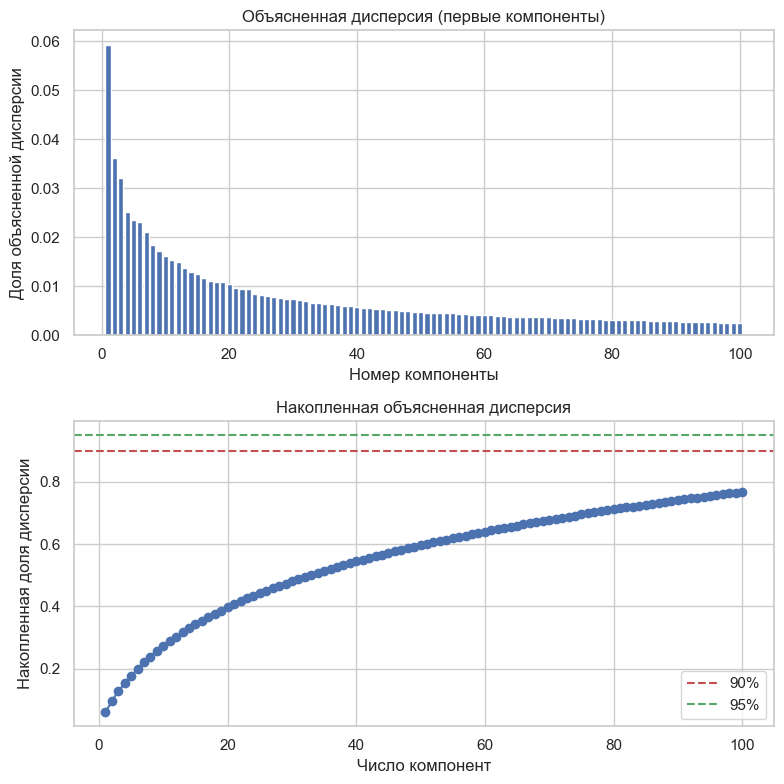


Набор: Mistral 7B 1
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [00:22<00:00,  4.27it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.6739
Стд. отклонение    |                     135.3673
Асимметрия         |                       1.4165
Эксцесс            |                       3.0962
95% квантиль       |                     637.3566
99% квантиль       |                     813.8915

Статистики расстояния Махаланобиса (ии)
Среднее            |                     479.5915
Стд. отклонение    |                     183.6094
Асимметрия         |                       1.5646
Эксцесс            |                       3.6246
95% квантиль       |                     842.0948
99% квантиль       |                    1072.0436

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.6975
PR-AUC                             : 0.6795


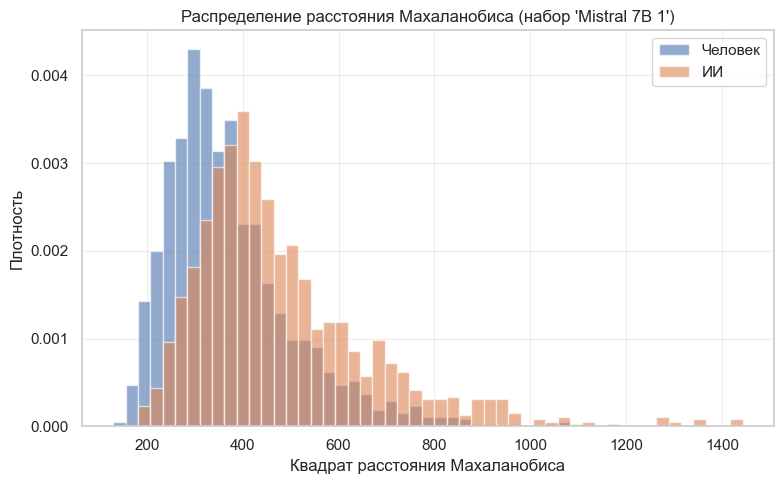

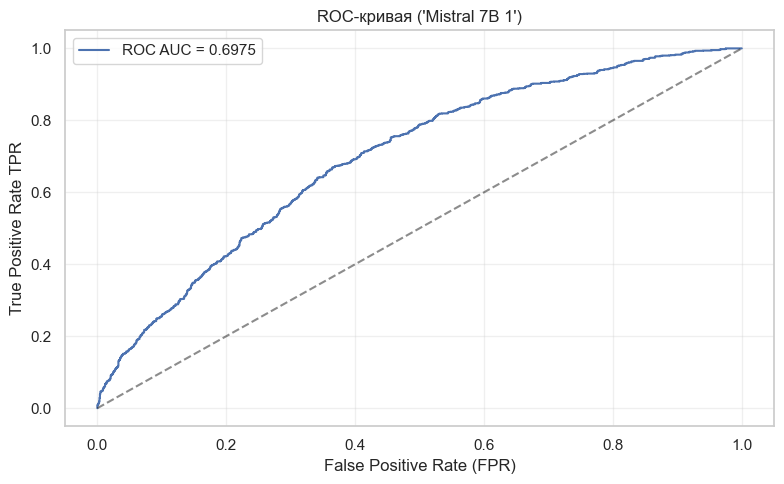

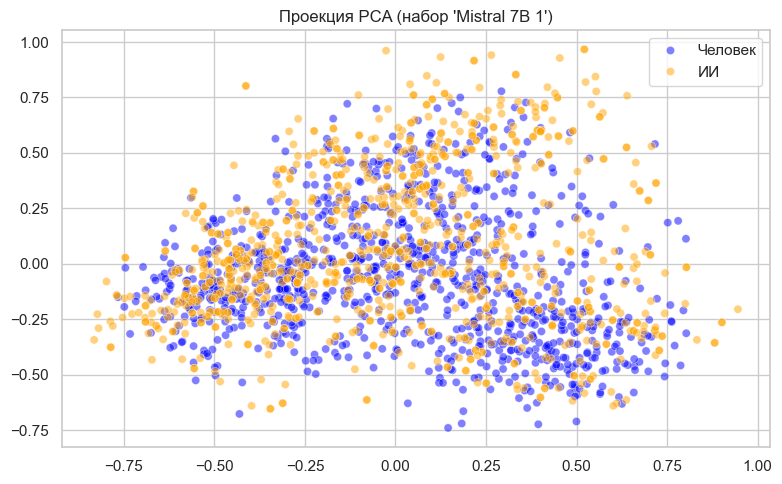


Набор: Mistral 7B 2
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [00:22<00:00,  4.22it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.6739
Стд. отклонение    |                     135.3673
Асимметрия         |                       1.4165
Эксцесс            |                       3.0962
95% квантиль       |                     637.3566
99% квантиль       |                     813.8915

Статистики расстояния Махаланобиса (ии)
Среднее            |                     508.0241
Стд. отклонение    |                     183.1915
Асимметрия         |                       1.7774
Эксцесс            |                       6.4957
95% квантиль       |                     861.0740
99% квантиль       |                    1115.3383

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7511
PR-AUC                             : 0.7220


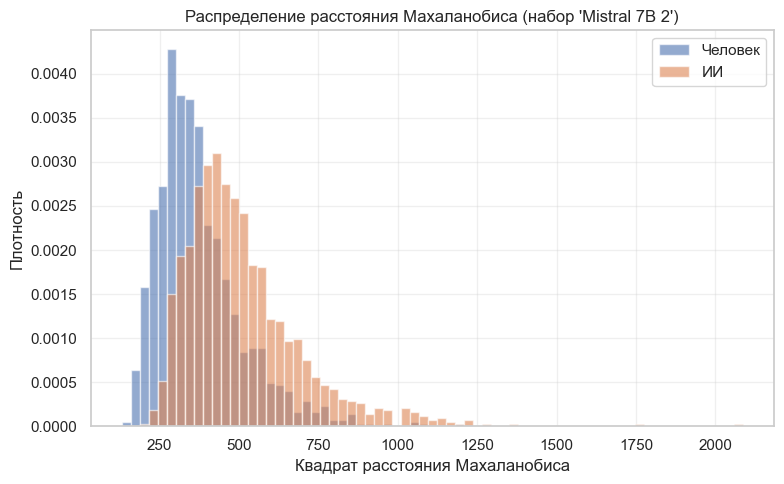

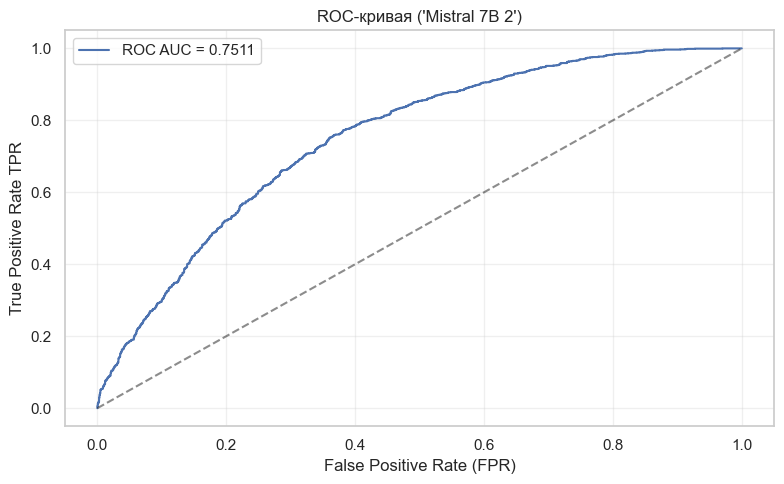

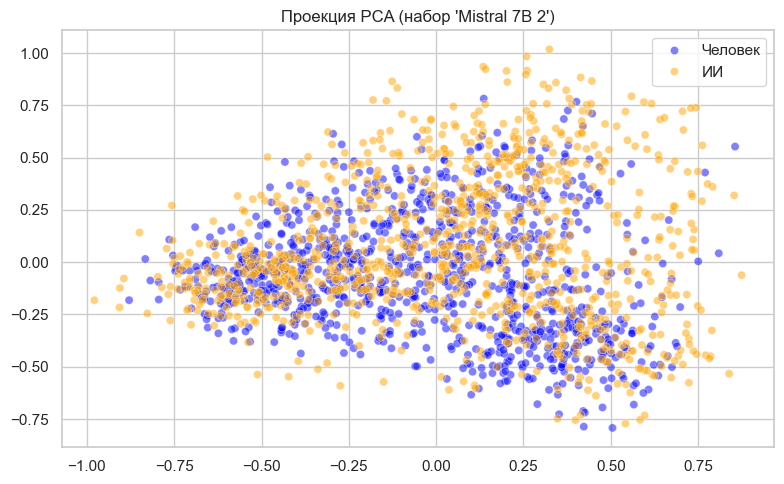


Набор: Mistral 7B 3
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [00:21<00:00,  4.28it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.6739
Стд. отклонение    |                     135.3673
Асимметрия         |                       1.4165
Эксцесс            |                       3.0962
95% квантиль       |                     637.3566
99% квантиль       |                     813.8915

Статистики расстояния Махаланобиса (ии)
Среднее            |                     505.3478
Стд. отклонение    |                     195.9645
Асимметрия         |                       1.9235
Эксцесс            |                       6.4510
95% квантиль       |                     890.9474
99% квантиль       |                    1174.4380

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7383
PR-AUC                             : 0.7145


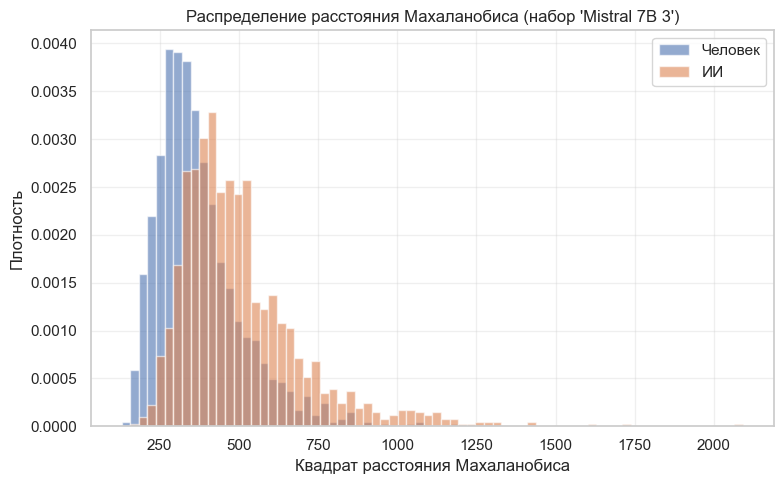

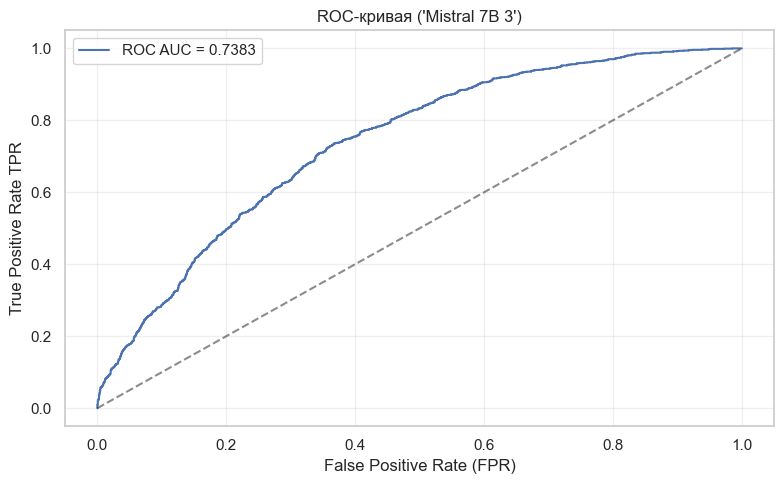

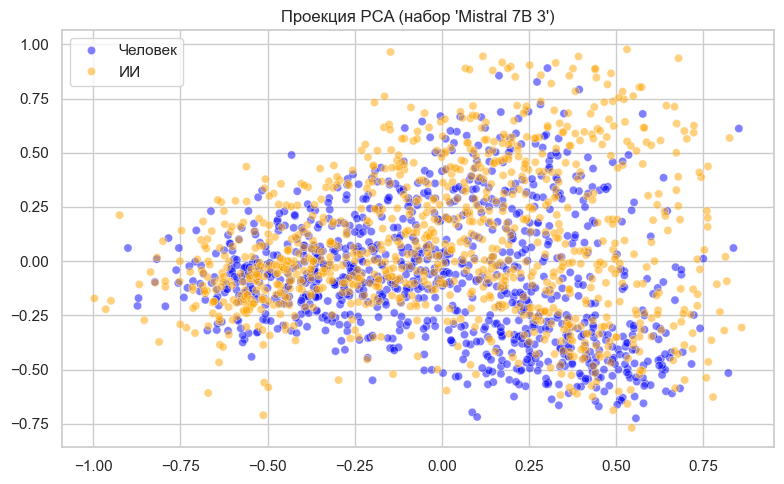


Набор: Mistral 7B 4
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [00:22<00:00,  4.21it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.6739
Стд. отклонение    |                     135.3673
Асимметрия         |                       1.4165
Эксцесс            |                       3.0962
95% квантиль       |                     637.3566
99% квантиль       |                     813.8915

Статистики расстояния Махаланобиса (ии)
Среднее            |                     496.5597
Стд. отклонение    |                     187.2199
Асимметрия         |                       1.8667
Эксцесс            |                       5.9724
95% квантиль       |                     850.1004
99% квантиль       |                    1150.5746

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7306
PR-AUC                             : 0.7039


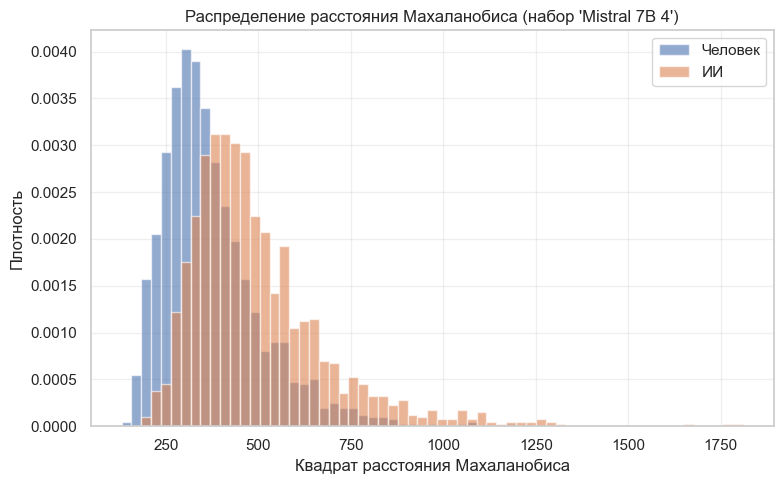

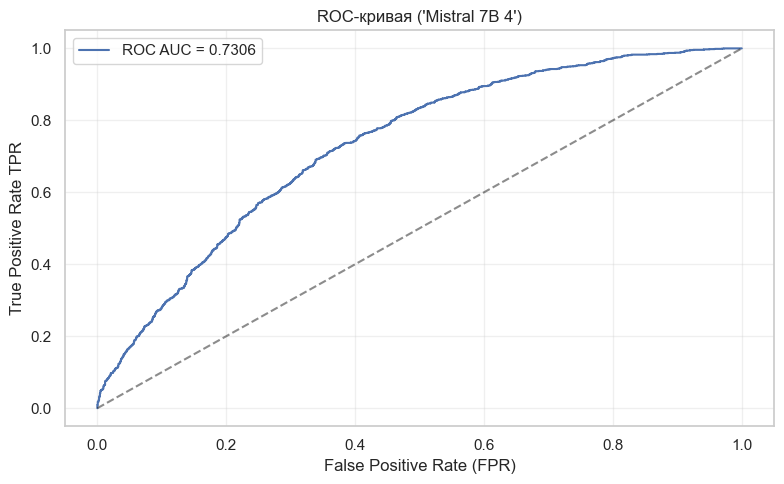

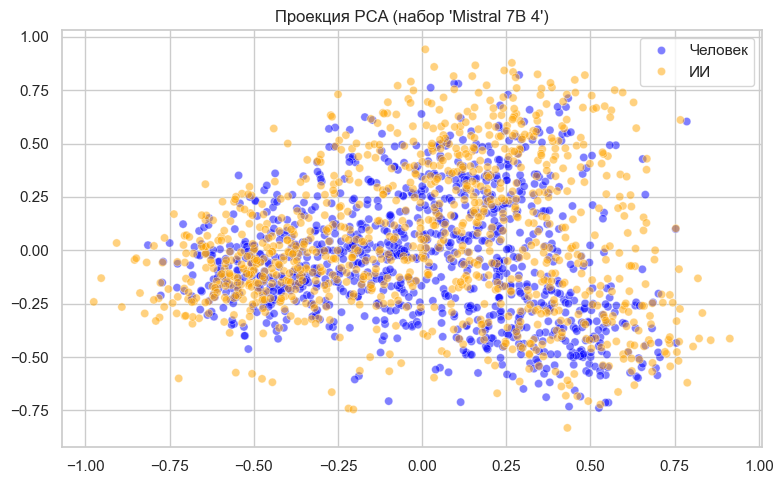


Набор: Mistral 7B 5
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [00:21<00:00,  4.32it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.6739
Стд. отклонение    |                     135.3673
Асимметрия         |                       1.4165
Эксцесс            |                       3.0962
95% квантиль       |                     637.3566
99% квантиль       |                     813.8915

Статистики расстояния Махаланобиса (ии)
Среднее            |                     505.9436
Стд. отклонение    |                     177.1945
Асимметрия         |                       1.8911
Эксцесс            |                       5.5794
95% квантиль       |                     863.5965
99% квантиль       |                    1125.2645

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7595
PR-AUC                             : 0.7192


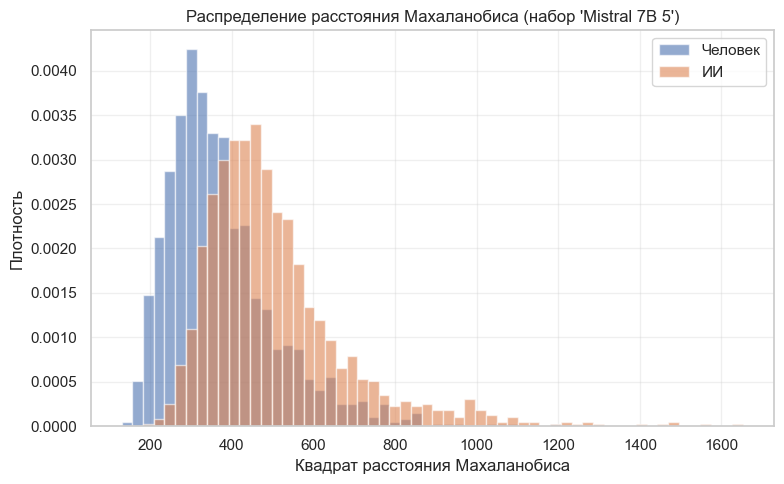

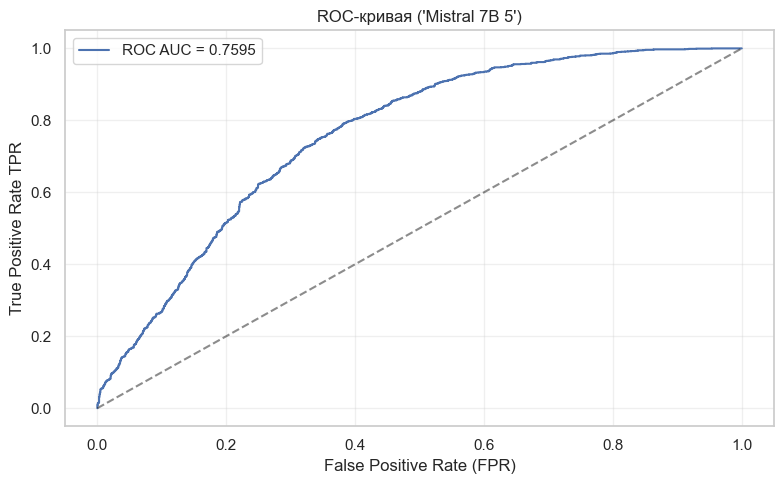

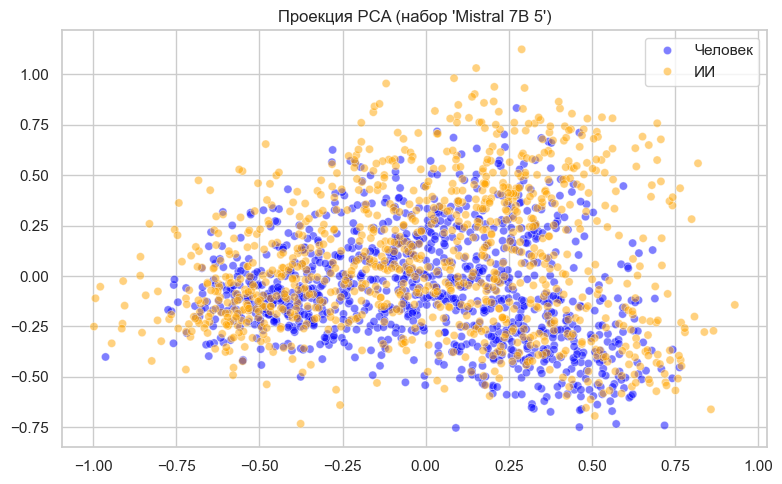


Набор: Llama 3 13B 1
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:14<00:00,  4.43it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     374.4440
Стд. отклонение    |                     135.9378
Асимметрия         |                       1.5053
Эксцесс            |                       3.7882
95% квантиль       |                     638.4423
99% квантиль       |                     813.9433

Статистики расстояния Махаланобиса (ии)
Среднее            |                     473.2824
Стд. отклонение    |                     180.5533
Асимметрия         |                       1.5430
Эксцесс            |                       3.1399
95% квантиль       |                     840.0414
99% квантиль       |                    1084.4093

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 999
ROC-AUC                            : 0.6842
PR-AUC                             : 0.6667


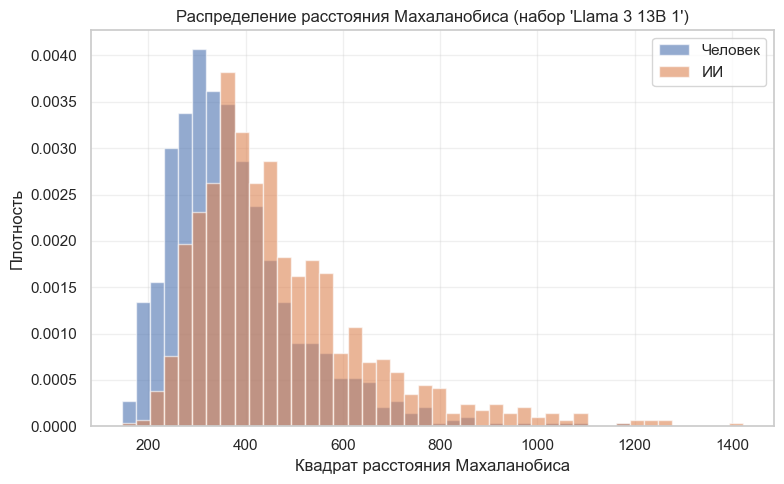

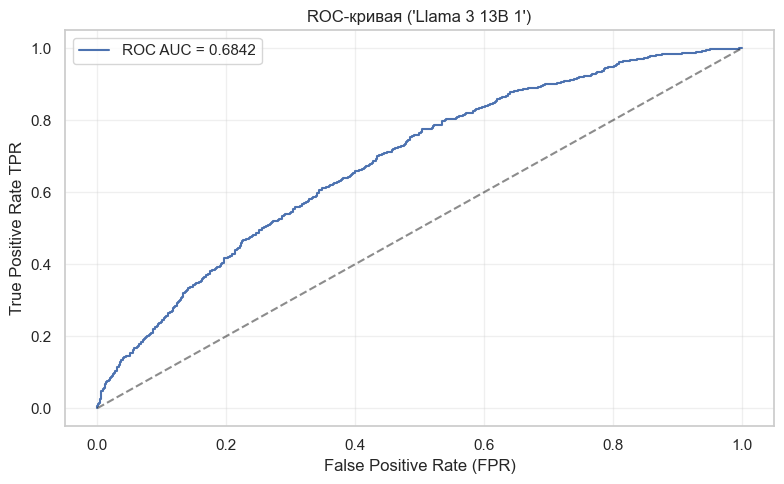

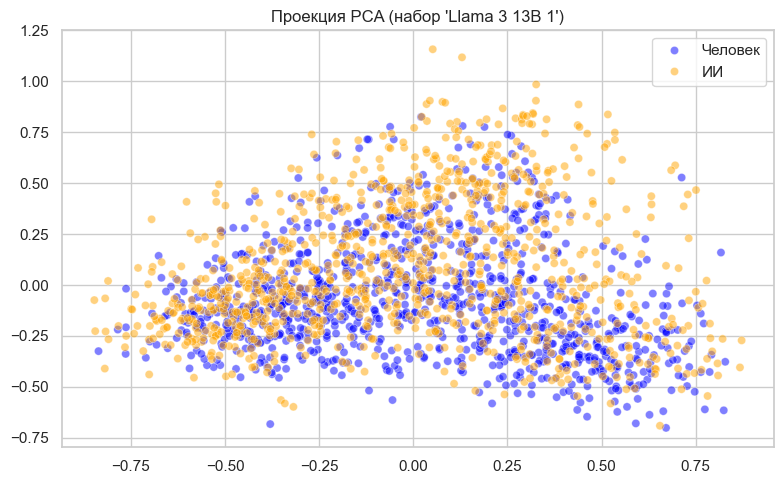


Набор: Llama 3 13B 2
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:14<00:00,  4.27it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     374.4397
Стд. отклонение    |                     135.8698
Асимметрия         |                       1.5062
Эксцесс            |                       3.7951
95% квантиль       |                     638.3802
99% квантиль       |                     813.8915

Статистики расстояния Махаланобиса (ии)
Среднее            |                     480.4894
Стд. отклонение    |                     175.9258
Асимметрия         |                       1.5750
Эксцесс            |                       3.4167
95% квантиль       |                     832.9195
99% квантиль       |                    1112.7351

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1000
ROC-AUC                            : 0.7061
PR-AUC                             : 0.6792


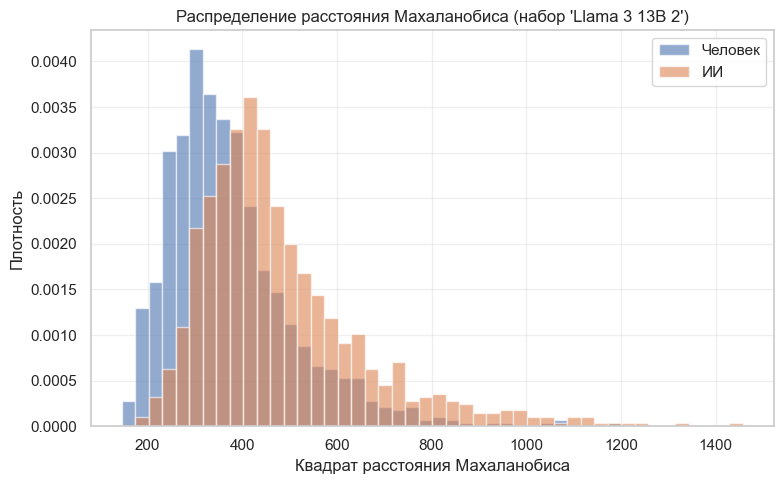

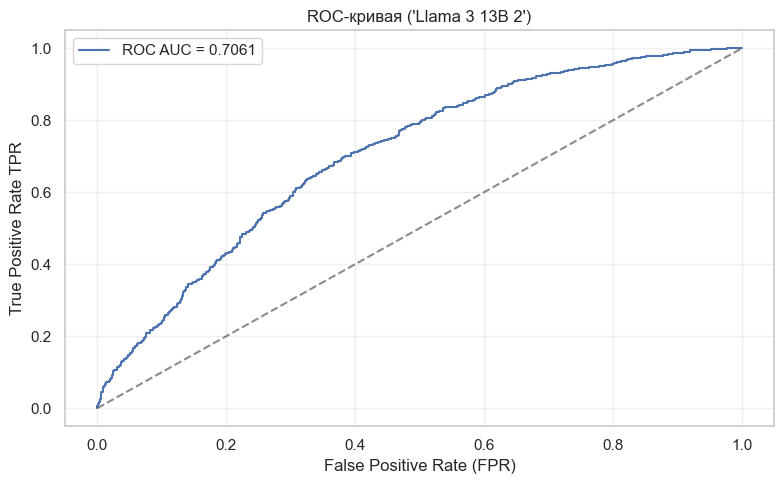

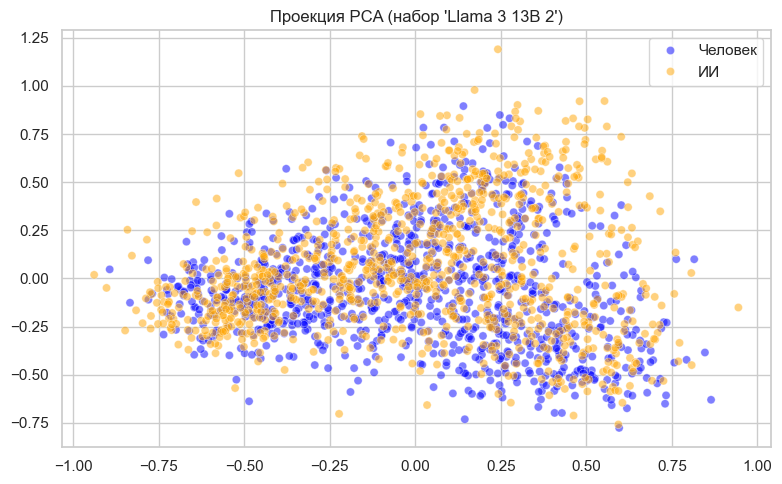


Набор: Llama 3 13B 3
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:15<00:00,  4.18it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     374.1481
Стд. отклонение    |                     135.9109
Асимметрия         |                       1.5124
Эксцесс            |                       3.8264
95% квантиль       |                     638.7532
99% квантиль       |                     814.2024

Статистики расстояния Махаланобиса (ии)
Среднее            |                     502.7148
Стд. отклонение    |                     191.3914
Асимметрия         |                       1.4110
Эксцесс            |                       2.5624
95% квантиль       |                     882.3519
99% квантиль       |                    1147.8888

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 994
ROC-AUC                            : 0.7254
PR-AUC                             : 0.7101


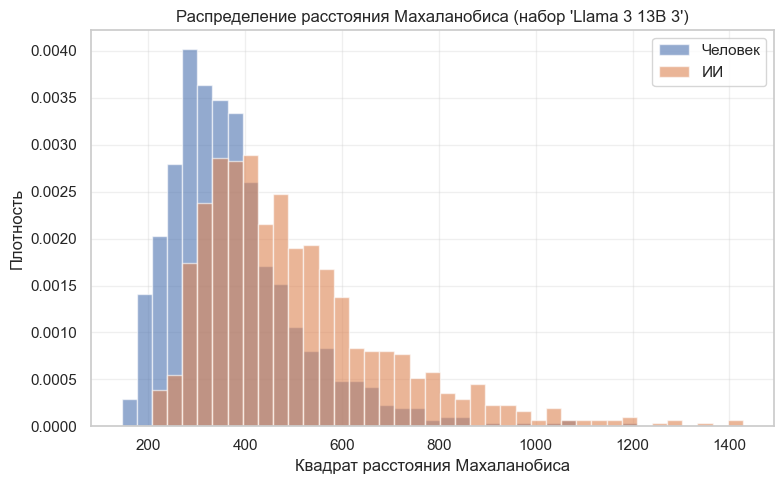

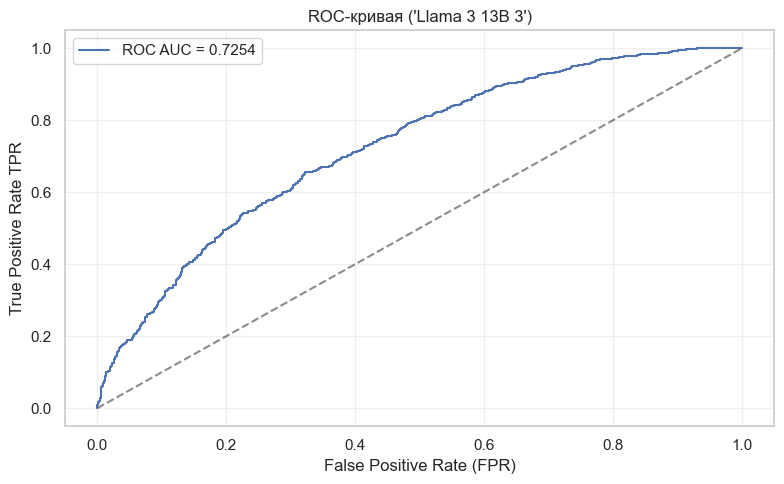

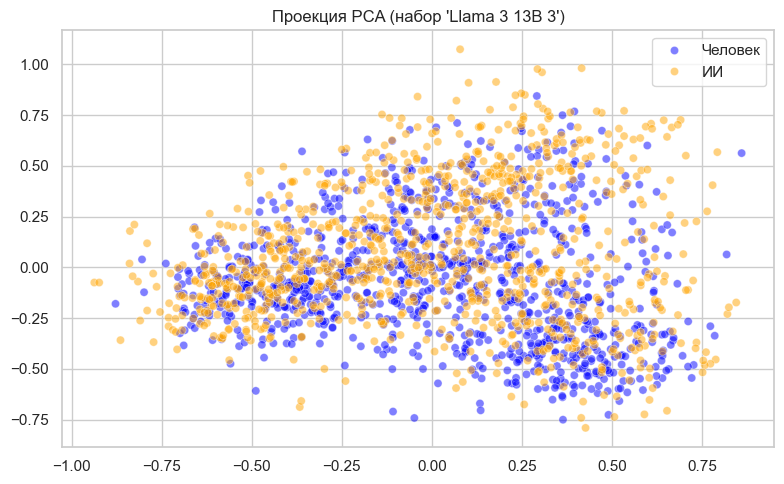


Набор: Llama 3 13B 4
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:14<00:00,  4.22it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     374.2702
Стд. отклонение    |                     135.8087
Асимметрия         |                       1.5101
Эксцесс            |                       3.8227
95% квантиль       |                     638.5667
99% квантиль       |                     814.0470

Статистики расстояния Махаланобиса (ии)
Среднее            |                     483.4754
Стд. отклонение    |                     189.2725
Асимметрия         |                       1.8782
Эксцесс            |                       5.5700
95% квантиль       |                     828.6455
99% квантиль       |                    1209.5771

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 997
ROC-AUC                            : 0.7006
PR-AUC                             : 0.6817


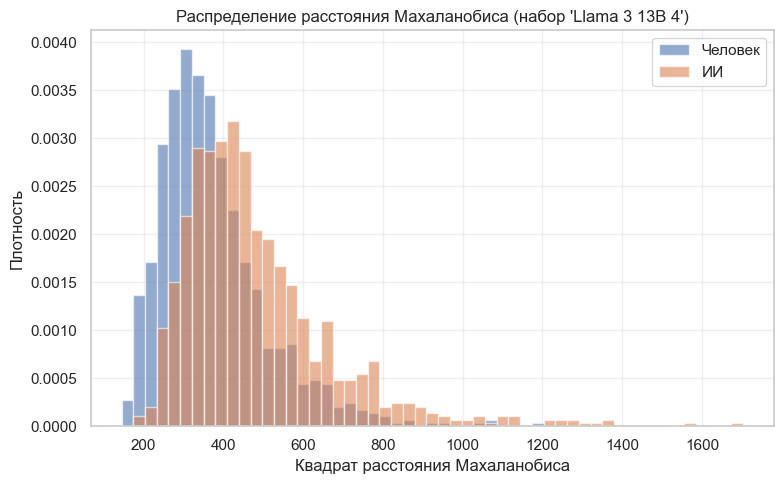

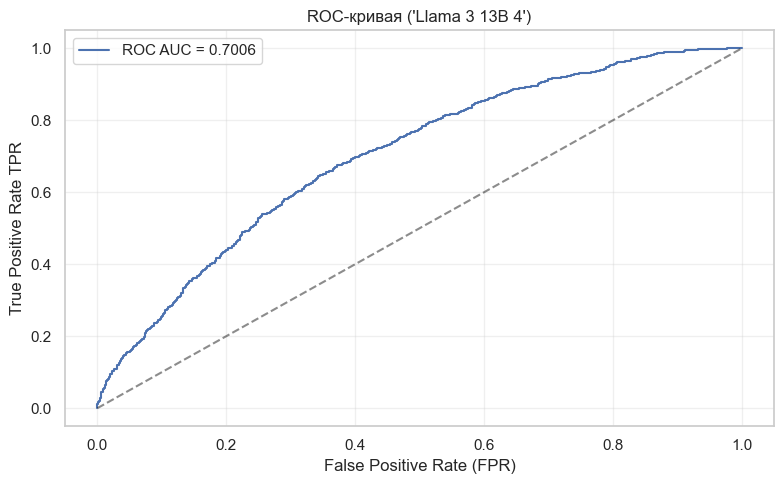

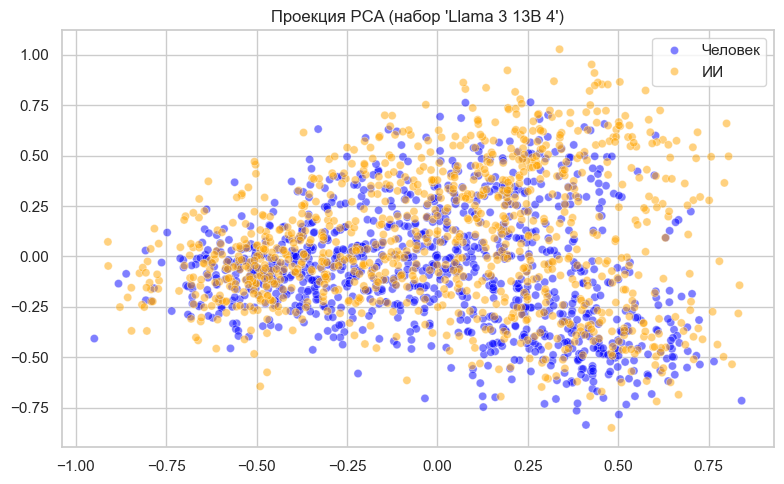


Набор: Llama 3 13B 5
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:14<00:00,  4.38it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     374.4440
Стд. отклонение    |                     135.9378
Асимметрия         |                       1.5053
Эксцесс            |                       3.7882
95% квантиль       |                     638.4423
99% квантиль       |                     813.9433

Статистики расстояния Махаланобиса (ии)
Среднее            |                     478.8507
Стд. отклонение    |                     230.1505
Асимметрия         |                       9.9022
Эксцесс            |                     193.3304
95% квантиль       |                     815.9380
99% квантиль       |                    1132.4075

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 999
ROC-AUC                            : 0.6973
PR-AUC                             : 0.6698


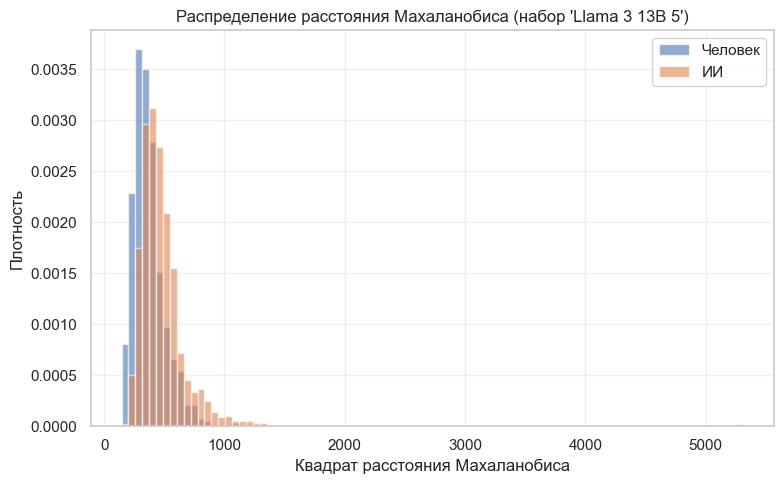

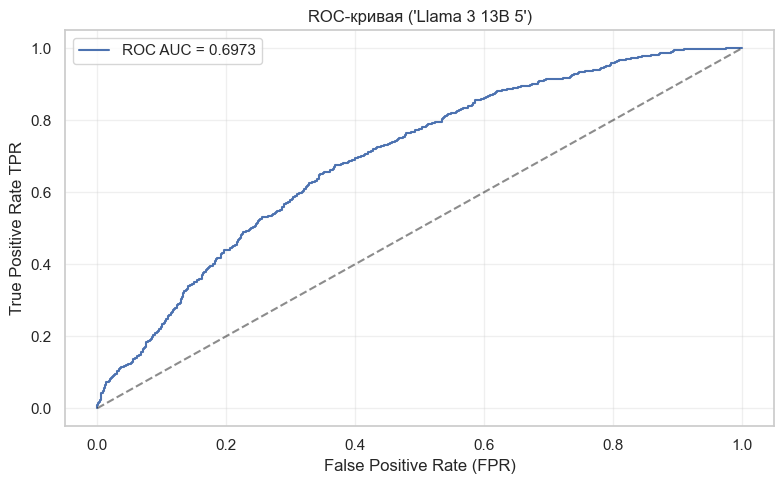

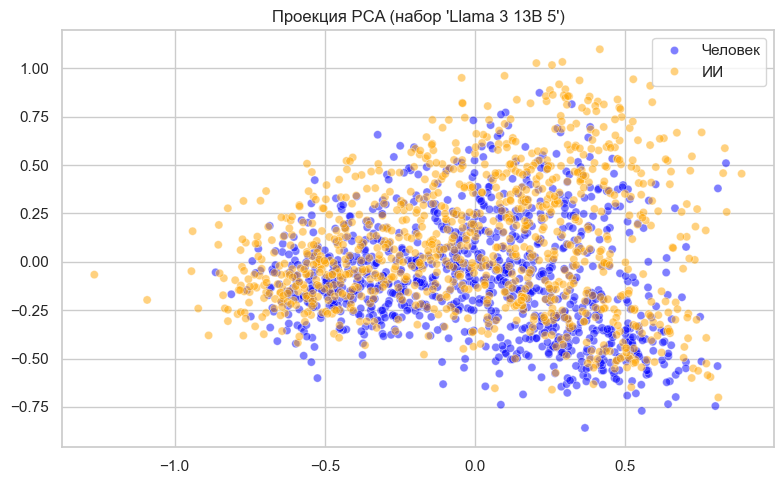


Набор: DeepSeek V3.2 1
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [00:44<00:00,  4.25it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.5334
Стд. отклонение    |                     137.3858
Асимметрия         |                       1.5217
Эксцесс            |                       3.6979
95% квантиль       |                     636.6610
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     417.9397
Стд. отклонение    |                     173.4903
Асимметрия         |                       2.0852
Эксцесс            |                       7.2475
95% квантиль       |                     778.1035
99% квантиль       |                    1022.1034

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.5787
PR-AUC                             : 0.5760


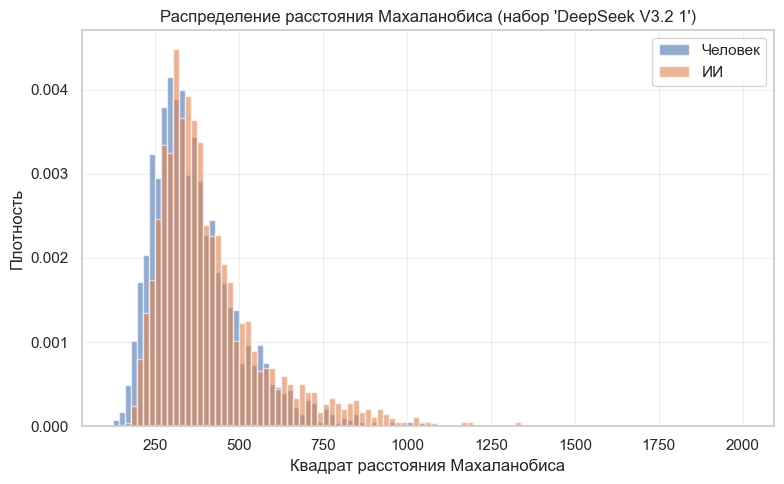

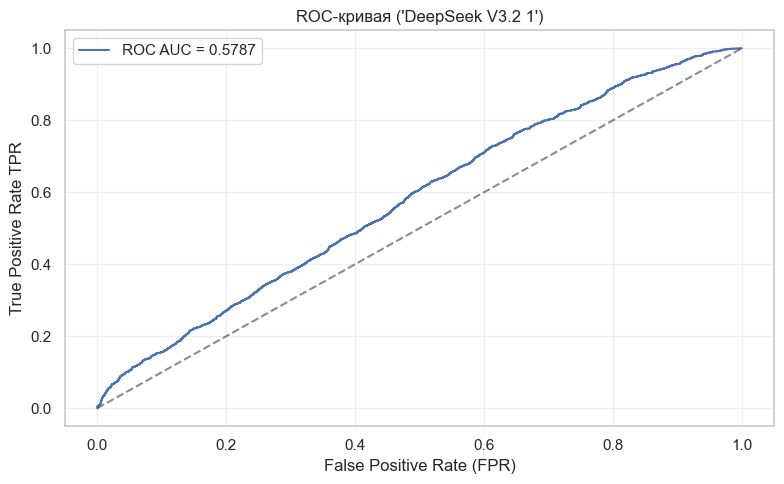

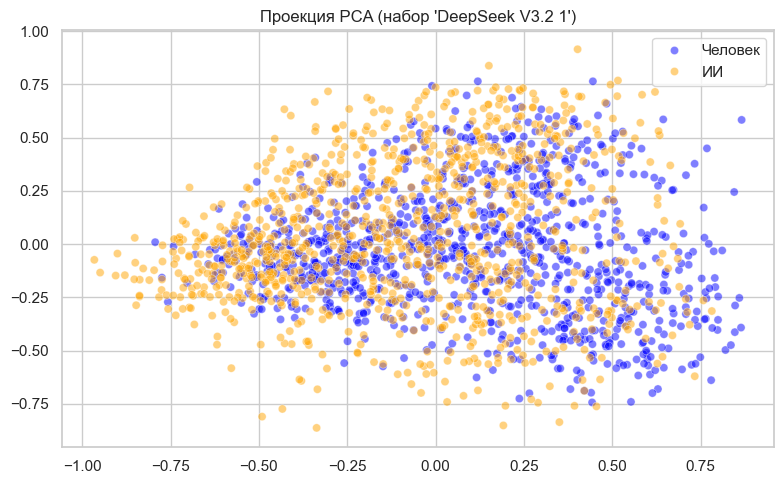


Набор: DeepSeek V3.2 2
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [00:43<00:00,  4.34it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.5334
Стд. отклонение    |                     137.3858
Асимметрия         |                       1.5217
Эксцесс            |                       3.6979
95% квантиль       |                     636.6610
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     436.2058
Стд. отклонение    |                     165.7160
Асимметрия         |                       1.7839
Эксцесс            |                       4.1695
95% квантиль       |                     784.9567
99% квантиль       |                    1012.4353

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.6293
PR-AUC                             : 0.6067


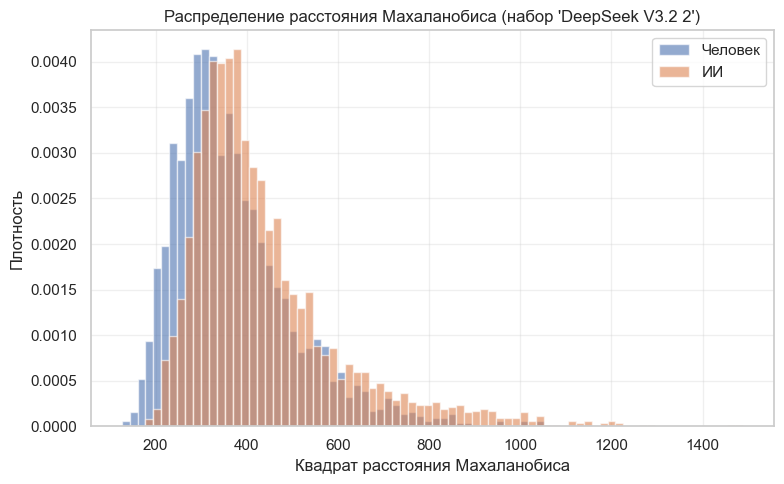

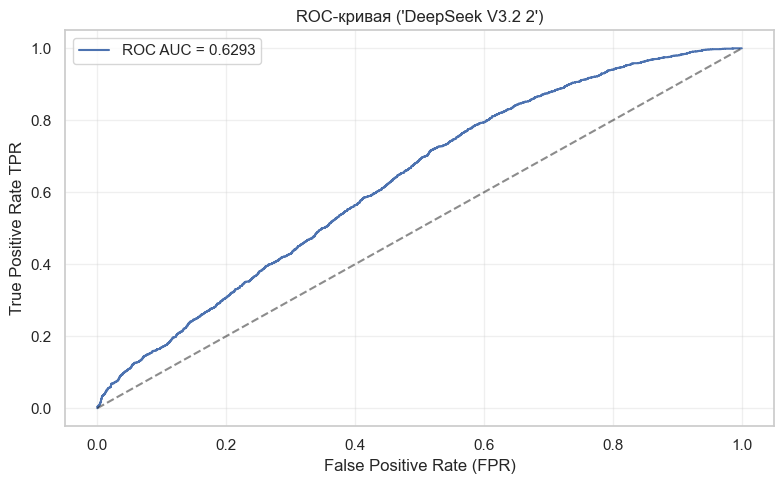

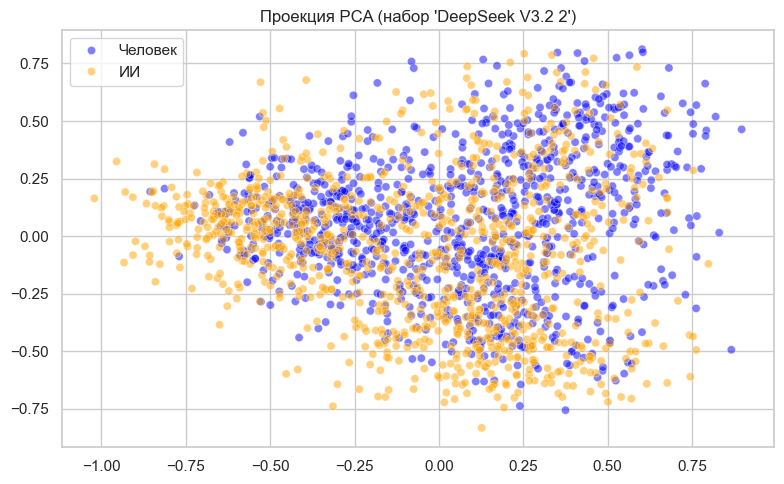


Набор: DeepSeek V3.2 3
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [00:43<00:00,  4.34it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.5660
Стд. отклонение    |                     137.3971
Асимметрия         |                       1.5213
Эксцесс            |                       3.6964
95% квантиль       |                     636.6717
99% квантиль       |                     840.8528

Статистики расстояния Махаланобиса (ии)
Среднее            |                     427.9124
Стд. отклонение    |                     175.9015
Асимметрия         |                       1.8081
Эксцесс            |                       4.6609
95% квантиль       |                     794.1391
99% квантиль       |                    1024.1298

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2999
ROC-AUC                            : 0.5968
PR-AUC                             : 0.5934


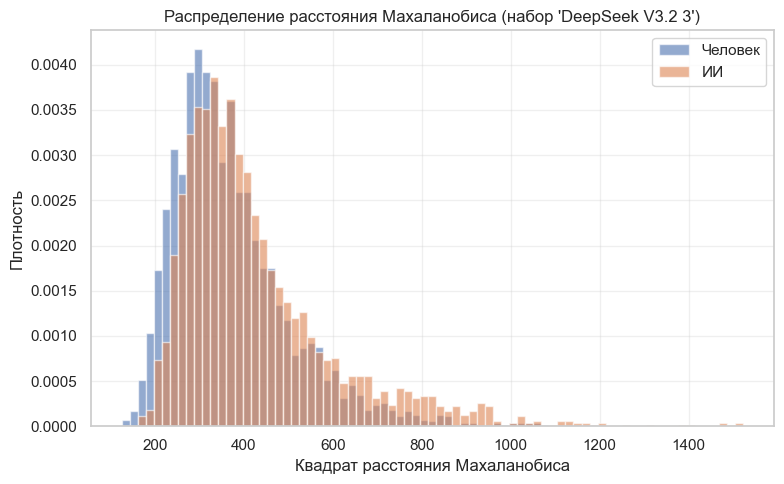

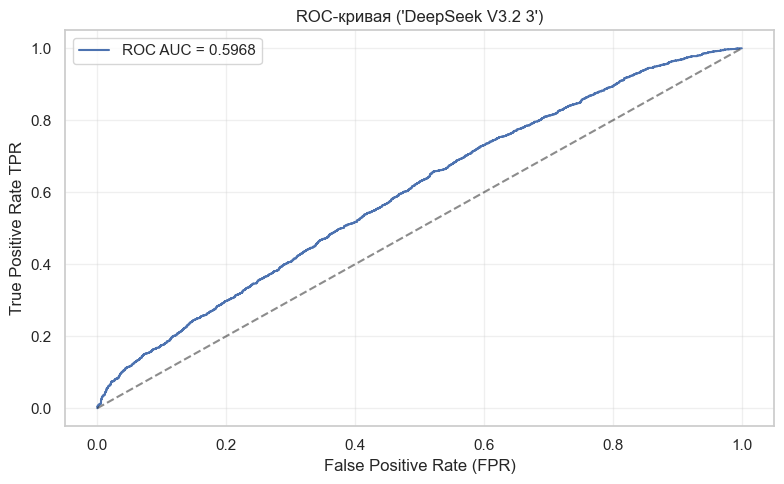

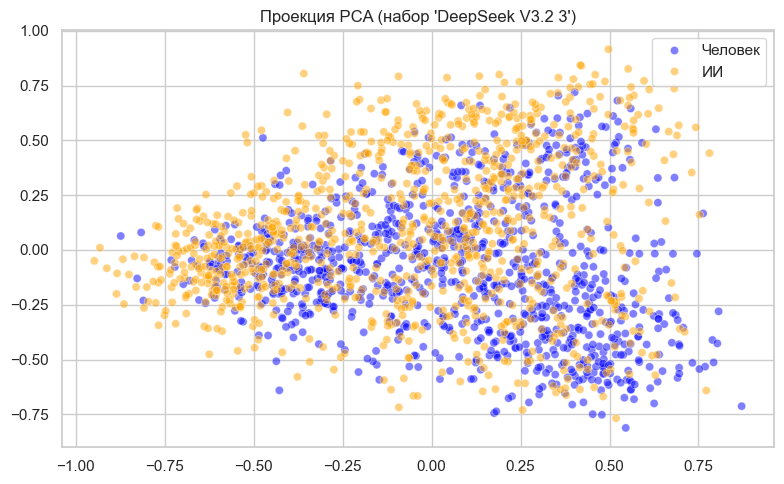


Набор: DeepSeek V3.2 4
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [00:44<00:00,  4.24it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.5334
Стд. отклонение    |                     137.3858
Асимметрия         |                       1.5217
Эксцесс            |                       3.6979
95% квантиль       |                     636.6610
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     425.3661
Стд. отклонение    |                     163.2909
Асимметрия         |                       1.7050
Эксцесс            |                       3.6696
95% квантиль       |                     767.4431
99% квантиль       |                    1027.6093

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.6042
PR-AUC                             : 0.5889


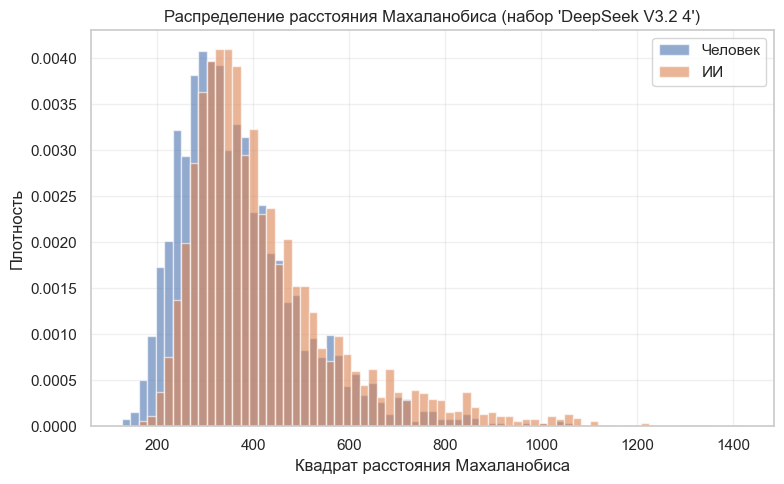

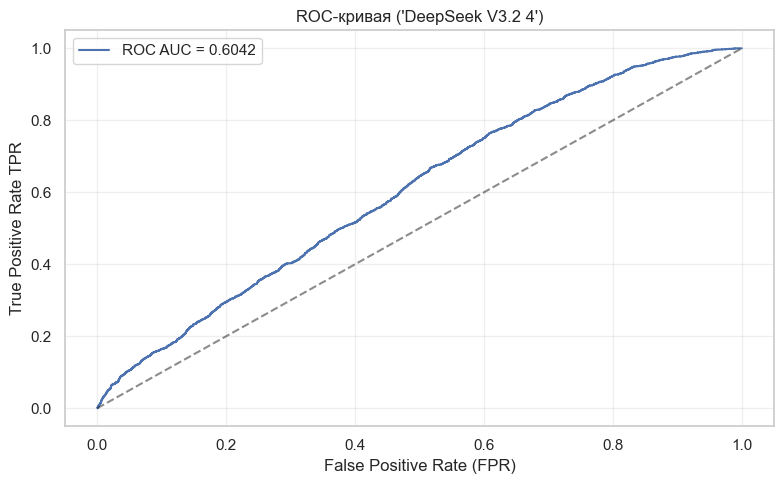

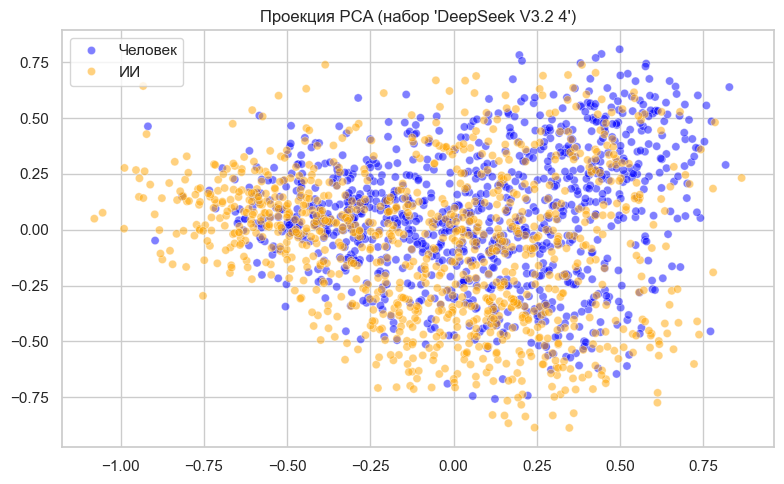


Набор: DeepSeek V3.2 5
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [00:43<00:00,  4.34it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     372.5334
Стд. отклонение    |                     137.3858
Асимметрия         |                       1.5217
Эксцесс            |                       3.6979
95% квантиль       |                     636.6610
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     440.0468
Стд. отклонение    |                     149.8160
Асимметрия         |                       1.8195
Эксцесс            |                       4.4694
95% квантиль       |                     760.1748
99% квантиль       |                     969.3125

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.6572
PR-AUC                             : 0.6130


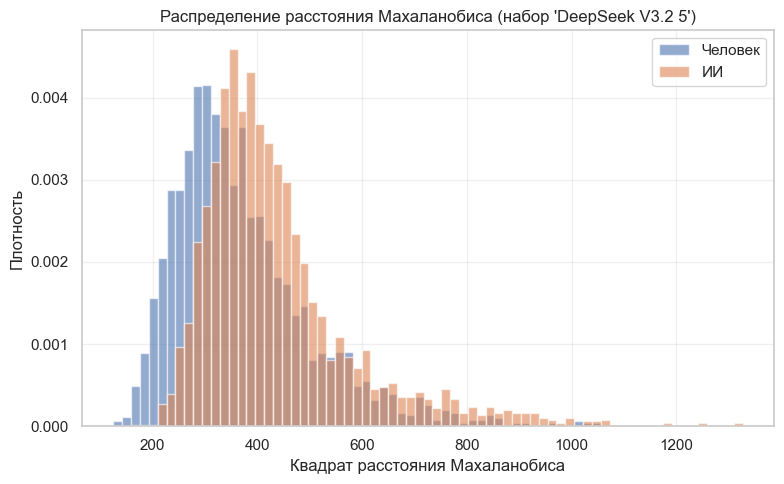

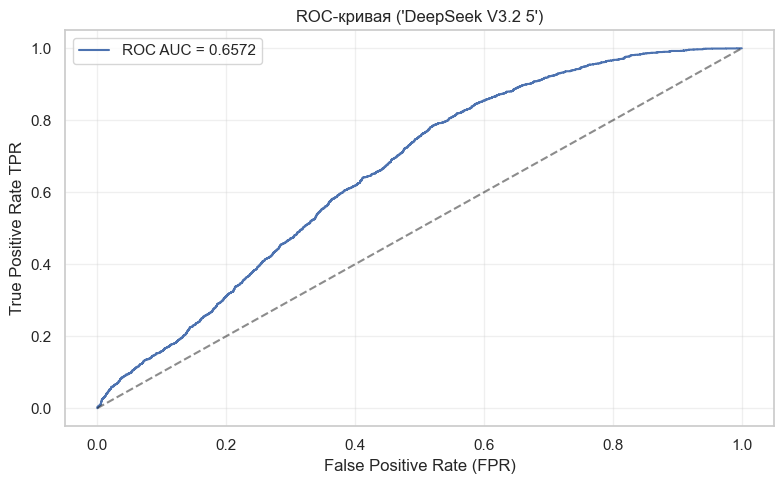

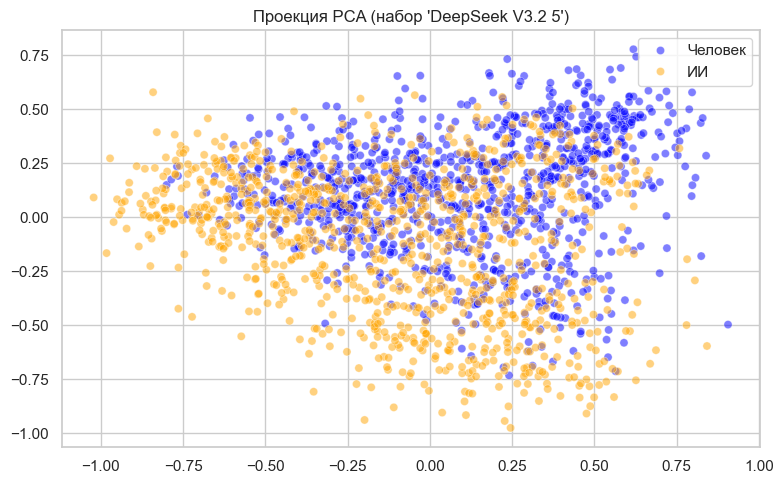


Набор: ChatGPT 1
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [00:29<00:00,  4.25it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     373.2087
Стд. отклонение    |                     138.6655
Асимметрия         |                       1.5179
Эксцесс            |                       3.5994
95% квантиль       |                     643.9748
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     474.3239
Стд. отклонение    |                     188.1734
Асимметрия         |                       1.6696
Эксцесс            |                       4.0099
95% квантиль       |                     854.6277
99% квантиль       |                    1129.0805

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6840
PR-AUC                             : 0.6662


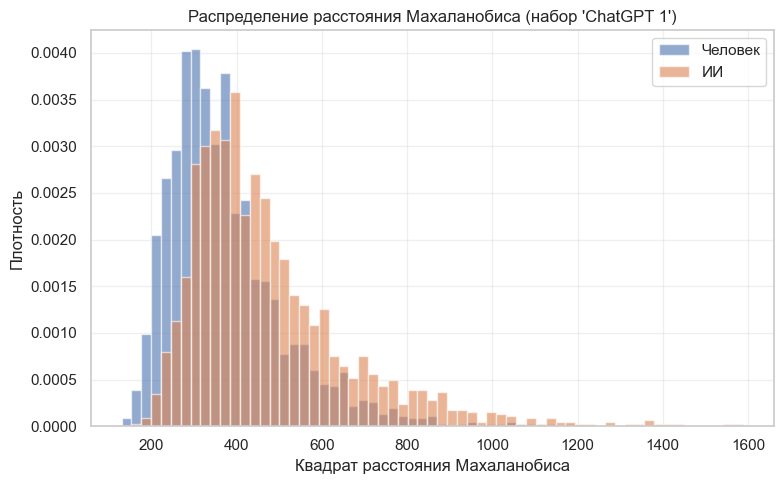

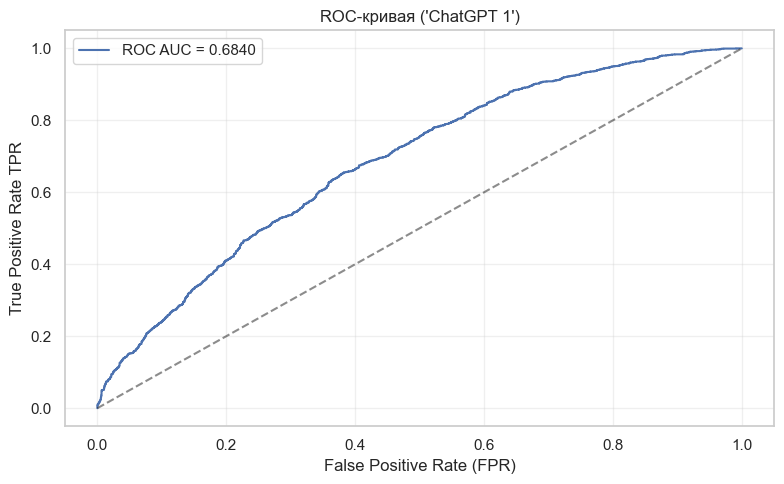

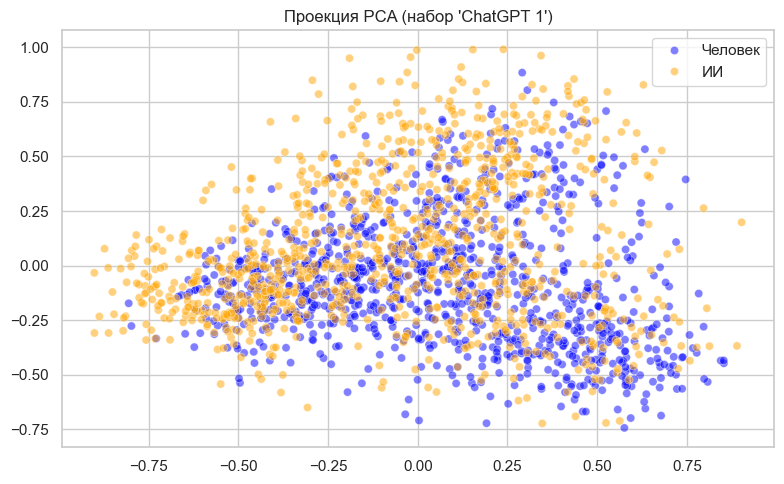


Набор: ChatGPT 2
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [00:29<00:00,  4.28it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     373.2087
Стд. отклонение    |                     138.6655
Асимметрия         |                       1.5179
Эксцесс            |                       3.5994
95% квантиль       |                     643.9748
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     517.7052
Стд. отклонение    |                     184.4483
Асимметрия         |                       1.4212
Эксцесс            |                       2.6461
95% квантиль       |                     890.0681
99% квантиль       |                    1150.4415

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.7629
PR-AUC                             : 0.7317


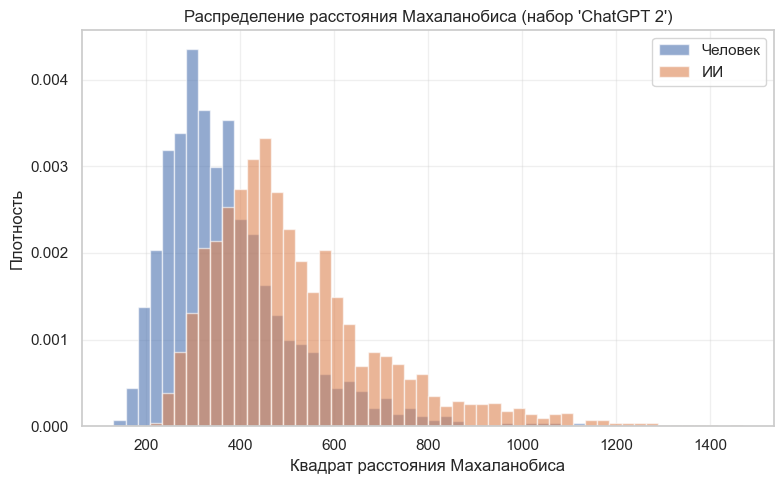

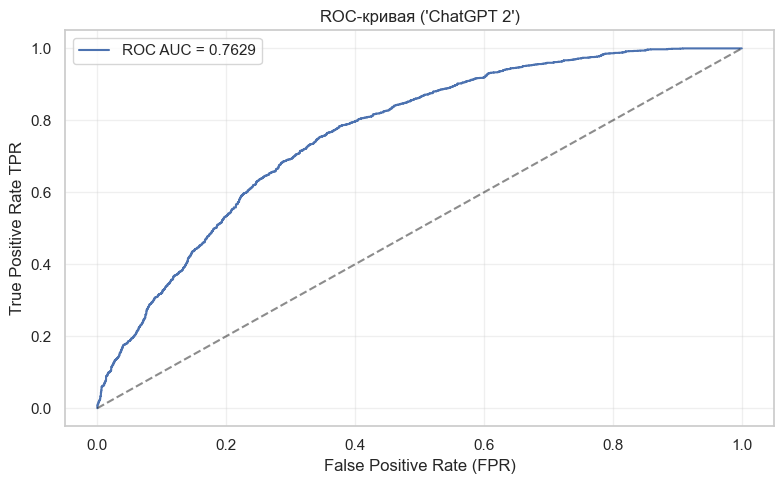

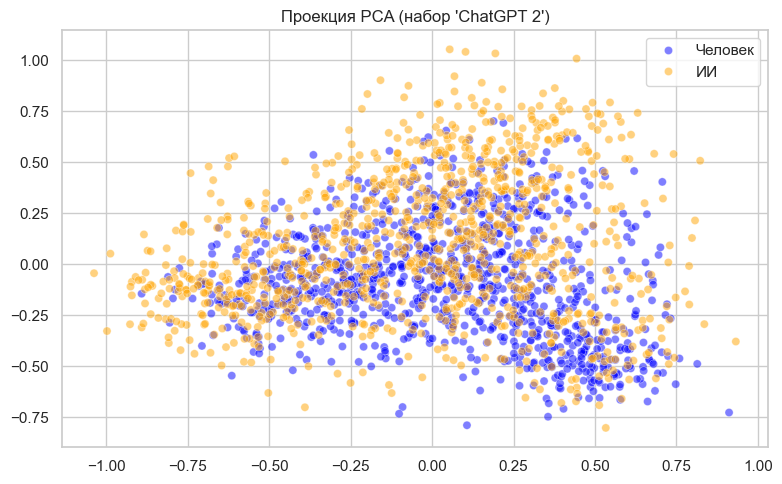


Набор: ChatGPT 3
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [00:29<00:00,  4.17it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     373.2087
Стд. отклонение    |                     138.6655
Асимметрия         |                       1.5179
Эксцесс            |                       3.5994
95% квантиль       |                     643.9748
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     481.5243
Стд. отклонение    |                     188.1644
Асимметрия         |                       1.5192
Эксцесс            |                       3.3740
95% квантиль       |                     843.3460
99% квантиль       |                    1098.7582

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6945
PR-AUC                             : 0.6777


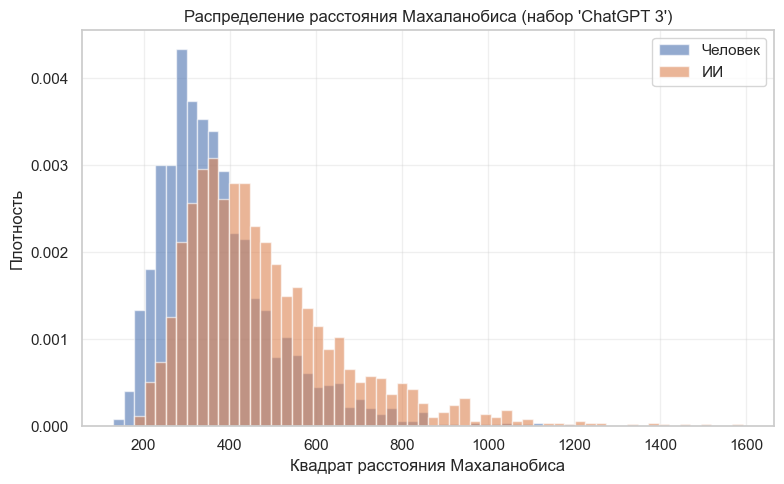

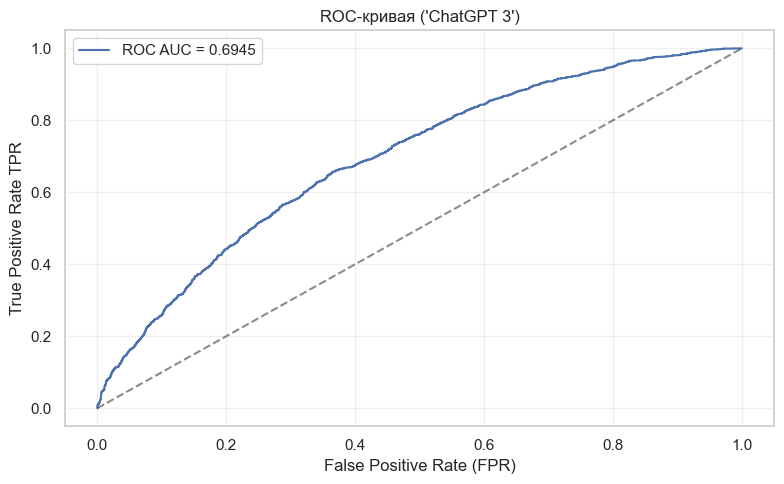

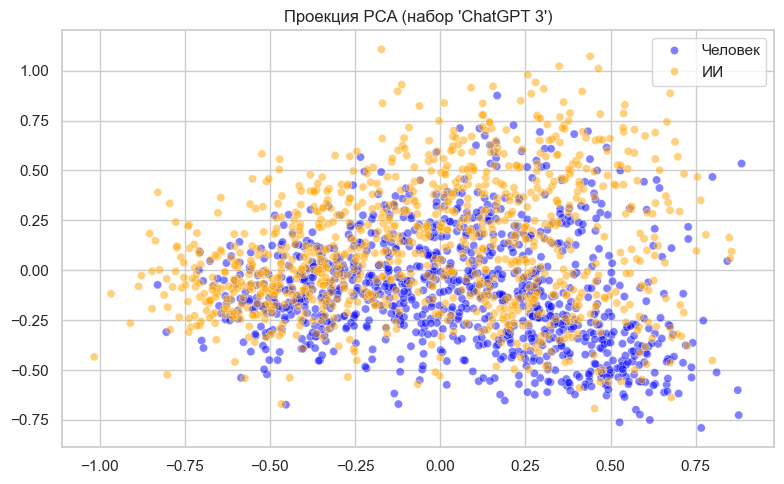


Набор: ChatGPT 4
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [00:30<00:00,  4.15it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     373.2087
Стд. отклонение    |                     138.6655
Асимметрия         |                       1.5179
Эксцесс            |                       3.5994
95% квантиль       |                     643.9748
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     491.4656
Стд. отклонение    |                     188.7179
Асимметрия         |                       1.9137
Эксцесс            |                       5.9727
95% квантиль       |                     866.0333
99% квантиль       |                    1134.7199

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.7207
PR-AUC                             : 0.6918


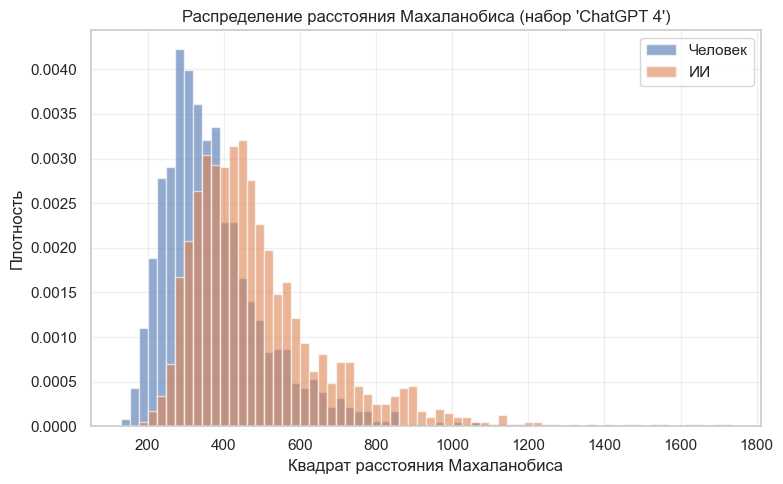

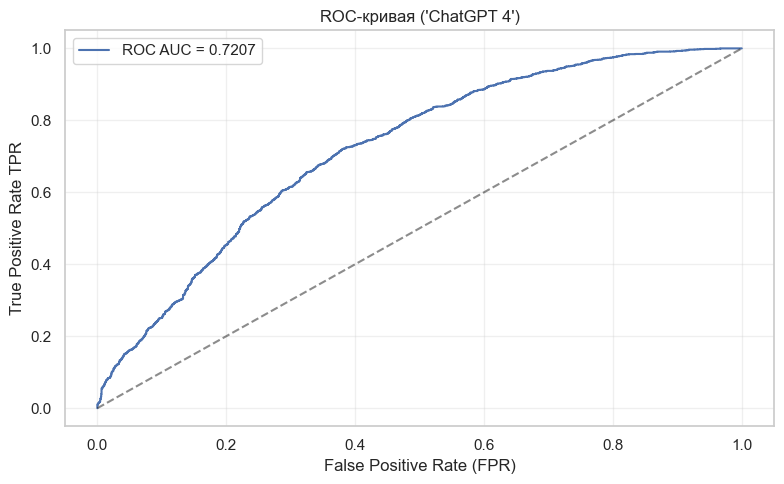

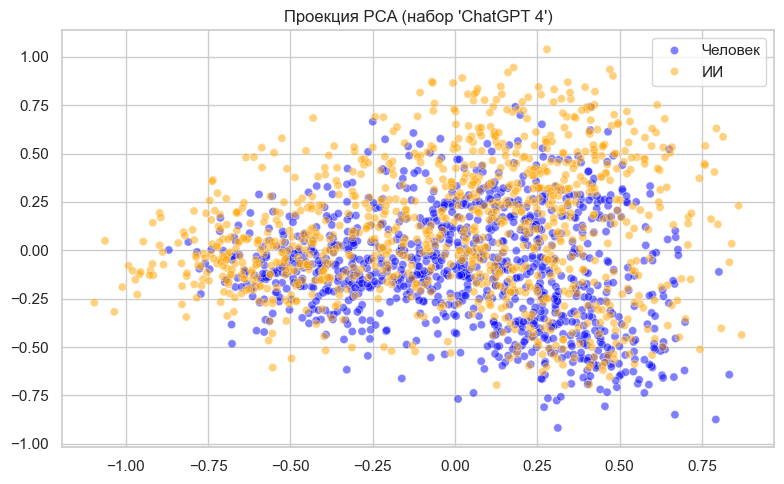


Набор: ChatGPT 5
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [00:27<00:00,  4.58it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     373.2087
Стд. отклонение    |                     138.6655
Асимметрия         |                       1.5179
Эксцесс            |                       3.5994
95% квантиль       |                     643.9748
99% квантиль       |                     840.8238

Статистики расстояния Махаланобиса (ии)
Среднее            |                     521.8118
Стд. отклонение    |                     182.1274
Асимметрия         |                       1.6252
Эксцесс            |                       3.9665
95% квантиль       |                     876.7474
99% квантиль       |                    1161.1013

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.7756
PR-AUC                             : 0.7377


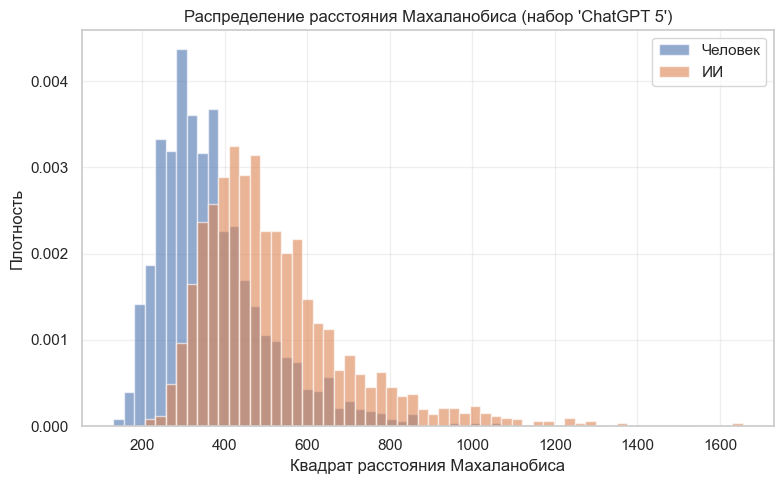

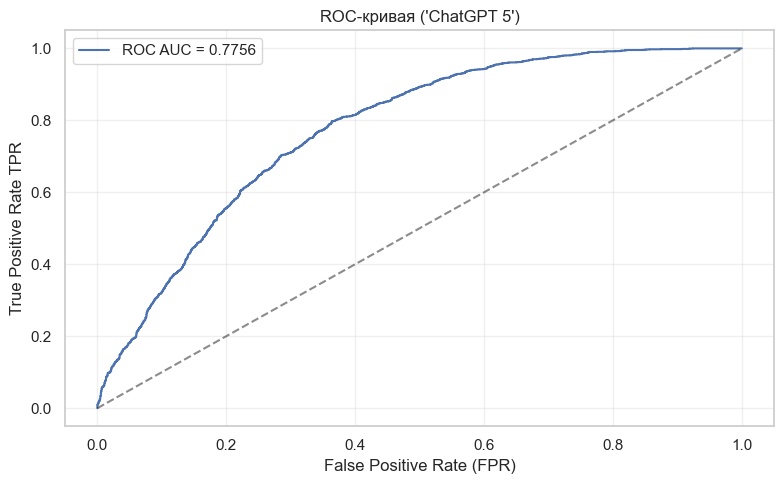

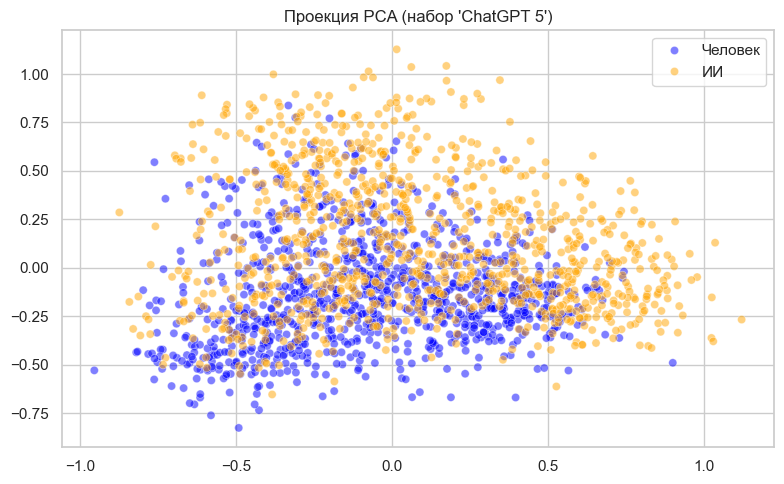

In [7]:
results = []

print_header(f"ENCODER: {ENCODER}")

tokenizer = AutoTokenizer.from_pretrained(ENCODER)
model = AutoModel.from_pretrained(ENCODER)

X_human = get_embeddings(tokenizer, model, human_df["text"])
X_human = X_human.numpy().astype(np.float32)

print_norm_stats(X_human)

X_h_train, X_h_test = train_test_split(
    X_human,
    test_size=0.3,
    random_state=SEED
)

print_kv("Эмбеддинги живых текстов (train)", len(X_h_train))
print_kv("Эмбеддинги живых текстов (test)", len(X_h_test))

cov = LedoitWolf().fit(X_h_train)
scores_h_train = cov.mahalanobis(X_h_train)

covariance_spectrum(cov)

for name, ai_df in ai_datasets.items():
    print(f"\nНабор: {name}")
    print("-" * 40)

    X_ai = get_embeddings(tokenizer, model, ai_df["text"])
    X_ai = X_ai.numpy().astype(np.float32)

    n = min(len(X_h_test), len(X_ai))

    X_test = np.vstack([X_h_test[:n], X_ai[:n]])
    y_test = np.concatenate([
        np.zeros(n, dtype=int),
        np.ones(n, dtype=int)
    ])

    scores = cov.mahalanobis(X_test)
    scores_human = scores[:n]
    scores_ai = scores[n:]

    print_mahalanobis_stats(scores_human, "человек")
    print_mahalanobis_stats(scores_ai, "ии")

    roc_auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)

    print_kv("Количество объектов в 0 классе", len(X_h_test))
    print_kv("Количество объектов в 1 классе", len(X_ai))
    print_kv("ROC-AUC", f"{roc_auc:.4f}")
    print_kv("PR-AUC", f"{ap:.4f}")

    plot_mahalanobis_distributions(scores_human, scores_ai, name)
    plot_roc_curve(y_test, scores, roc_auc, name)
    plot_pca_projection(X_h_test, X_ai, name)

    results.append({
        "dataset": name,
        "size": len(X_test),
        "roc_auc": roc_auc,
        "pr_auc": ap
    })

In [8]:
results_df = pd.DataFrame(results)
print(results_df)

            dataset  size   roc_auc    pr_auc
0      Mistral 7B 1  3000  0.697523  0.679506
1      Mistral 7B 2  3000  0.751072  0.722020
2      Mistral 7B 3  3000  0.738344  0.714465
3      Mistral 7B 4  3000  0.730640  0.703934
4      Mistral 7B 5  3000  0.759489  0.719244
5     Llama 3 13B 1  1998  0.684165  0.666714
6     Llama 3 13B 2  2000  0.706093  0.679172
7     Llama 3 13B 3  1988  0.725370  0.710070
8     Llama 3 13B 4  1994  0.700582  0.681707
9     Llama 3 13B 5  1998  0.697283  0.669775
10  DeepSeek V3.2 1  6000  0.578710  0.575984
11  DeepSeek V3.2 2  6000  0.629277  0.606669
12  DeepSeek V3.2 3  5998  0.596849  0.593414
13  DeepSeek V3.2 4  6000  0.604189  0.588856
14  DeepSeek V3.2 5  6000  0.657246  0.612984
15        ChatGPT 1  4000  0.683951  0.666200
16        ChatGPT 2  4000  0.762942  0.731703
17        ChatGPT 3  4000  0.694527  0.677715
18        ChatGPT 4  4000  0.720657  0.691841
19        ChatGPT 5  4000  0.775624  0.737739
